## Backward Calculation of Implied Probabilities - Start: Feb 2026

In [1]:
import pandas as pd
import numpy as np

cme_feb_2026 = pd.read_csv("../../data/raw/CME/CME_FEB_2026.csv")
cme_feb_2026 = cme_feb_2026.reset_index(drop = True)
cme_feb_2026["time"] = pd.to_datetime(cme_feb_2026["time"],unit="s") 

In [3]:
cme_feb_2026

,time,open,high,low,close,Volume
0,2025-09-26 19:46:00,96.400,96.400,96.400,96.400,32
1,2025-09-26 19:55:00,96.400,96.400,96.400,96.400,423
2,2025-09-26 20:01:00,96.405,96.405,96.405,96.405,705
3,2025-09-26 20:02:00,96.405,96.405,96.405,96.405,39
4,2025-09-26 20:03:00,96.405,96.405,96.405,96.405,9
...,...,...,...,...,...,...
19994,2026-02-27 21:05:00,96.360,96.360,96.360,96.360,1
19995,2026-02-27 21:17:00,96.360,96.360,96.360,96.360,2
19996,2026-02-27 21:22:00,96.360,96.360,96.360,96.360,8
19997,2026-02-27 21:28:00,96.360,96.360,96.360,96.360,1


## CME End: Jan 2026

In [4]:
cme_jan_2026 = pd.read_csv("../../data/raw/CME/CME_JAN_2026.csv")
cme_jan_2026 = cme_jan_2026.reset_index(drop = True)
cme_jan_2026["time"] = pd.to_datetime(cme_jan_2026["time"],unit="s") 

In [5]:
cme_jan_2026

,time,open,high,low,close,Volume
0,2025-09-09 14:58:00,96.365,96.365,96.365,96.365,100
1,2025-09-09 15:03:00,96.360,96.360,96.360,96.360,670
2,2025-09-09 15:06:00,96.360,96.360,96.360,96.360,513
3,2025-09-09 15:07:00,96.360,96.360,96.360,96.360,105
4,2025-09-09 15:08:00,96.360,96.360,96.360,96.360,134
...,...,...,...,...,...,...
19994,2026-01-30 12:59:00,96.360,96.360,96.360,96.360,80
19995,2026-01-30 14:21:00,96.360,96.360,96.360,96.360,22
19996,2026-01-30 15:31:00,96.360,96.360,96.360,96.360,8
19997,2026-01-30 16:29:00,96.360,96.360,96.360,96.360,6


## Merge

In [6]:
feb = cme_feb_2026.copy()
feb["time"] = pd.to_datetime(feb["time"], unit="s")

if feb["time"].dt.tz is None:
    feb["time"] = feb["time"].dt.tz_localize("UTC")
else:
    feb["time"] = feb["time"].dt.tz_convert("UTC")

feb = feb.sort_values("time").set_index("time")
feb = feb.add_suffix("_feb_2026")

jan = cme_jan_2026.copy()
jan["time"] = pd.to_datetime(jan["time"], unit="s")

if jan["time"].dt.tz is None:
    jan["time"] = jan["time"].dt.tz_localize("UTC")
else:
    jan["time"] = jan["time"].dt.tz_convert("UTC")

jan = jan.sort_values("time").set_index("time")
jan = jan.add_suffix("_jan_2026")

In [7]:
final_df = feb.join(jan, how="left")

In [8]:
final_df = final_df.dropna()

In [9]:
final_df = final_df.reset_index()

In [10]:
final_df

,time,open_feb_2026,high_feb_2026,low_feb_2026,close_feb_2026,Volume_feb_2026,open_jan_2026,high_jan_2026,low_jan_2026,close_jan_2026,Volume_jan_2026
0,2025-09-26 20:01:00+00:00,96.405,96.405,96.405,96.405,705,96.32,96.32,96.32,96.32,35.0
1,2025-09-26 20:02:00+00:00,96.405,96.405,96.405,96.405,39,96.32,96.32,96.32,96.32,26.0
2,2025-09-26 20:11:00+00:00,96.405,96.405,96.405,96.405,2,96.32,96.32,96.32,96.32,6.0
3,2025-09-26 20:13:00+00:00,96.405,96.405,96.405,96.405,4,96.32,96.32,96.32,96.32,10.0
4,2025-09-26 20:16:00+00:00,96.400,96.400,96.400,96.400,5,96.32,96.32,96.32,96.32,7.0
...,...,...,...,...,...,...,...,...,...,...,...
7872,2026-01-29 21:44:00+00:00,96.365,96.365,96.365,96.365,1,96.36,96.36,96.36,96.36,204.0
7873,2026-01-29 23:04:00+00:00,96.370,96.370,96.370,96.370,9,96.36,96.36,96.36,96.36,8.0
7874,2026-01-30 10:14:00+00:00,96.365,96.365,96.365,96.365,1,96.36,96.36,96.36,96.36,30.0
7875,2026-01-30 11:59:00+00:00,96.365,96.365,96.365,96.365,40,96.36,96.36,96.36,96.36,1.0


## Calculate Implied Probabilities

In [11]:
meeting_day = 28
days_in_jan = 31

N = meeting_day           
M = days_in_jan - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jan"] = 100 - final_df["close_jan_2026"]
imp_df["effr_avg_feb"] = 100 - final_df["close_feb_2026"]

imp_df["effr_start_feb"] = imp_df["effr_avg_feb"]
imp_df["effr_end_jan"] = imp_df["effr_start_feb"]
imp_df["volume"] = final_df["Volume_jan_2026"]


In [12]:
imp_df["effr_start_jan"] = (
    imp_df["effr_avg_jan"] - (M / (N + M)) * imp_df["effr_end_jan"]
) / (N / (N + M))

In [13]:
imp_df["delta_effr"] = imp_df["effr_end_jan"] - imp_df["effr_start_jan"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [14]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [15]:
imp_df

,time,effr_avg_jan,effr_avg_feb,effr_start_feb,effr_end_jan,volume,effr_start_jan,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-09-26 20:01:00+00:00,3.68,3.595,3.595,3.595,35.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.0,0.0,0.0,0.0
1,2025-09-26 20:02:00+00:00,3.68,3.595,3.595,3.595,26.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.0,0.0,0.0,0.0
2,2025-09-26 20:11:00+00:00,3.68,3.595,3.595,3.595,6.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.0,0.0,0.0,0.0
3,2025-09-26 20:13:00+00:00,3.68,3.595,3.595,3.595,10.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.0,0.0,0.0,0.0
4,2025-09-26 20:16:00+00:00,3.68,3.600,3.600,3.600,7.0,3.688571,-0.088571,-0.354286,-1.0,0.645714,0.0,0.0,0.0,0.354286,0.645714,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7872,2026-01-29 21:44:00+00:00,3.64,3.635,3.635,3.635,204.0,3.640536,-0.005536,-0.022143,-1.0,0.977857,0.0,0.0,0.0,0.022143,0.977857,0.0,0.0,0.0,0.0
7873,2026-01-29 23:04:00+00:00,3.64,3.630,3.630,3.630,8.0,3.641071,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.0,0.0,0.0,0.0
7874,2026-01-30 10:14:00+00:00,3.64,3.635,3.635,3.635,30.0,3.640536,-0.005536,-0.022143,-1.0,0.977857,0.0,0.0,0.0,0.022143,0.977857,0.0,0.0,0.0,0.0
7875,2026-01-30 11:59:00+00:00,3.64,3.635,3.635,3.635,1.0,3.640536,-0.005536,-0.022143,-1.0,0.977857,0.0,0.0,0.0,0.022143,0.977857,0.0,0.0,0.0,0.0


## Filter Based on Decision Date


In [16]:
fomc_2026_utc = {
    "January 2026": pd.Timestamp("2026-01-28 19:00:00", tz="UTC"),   # Winter (Standard Time)
    "March 2026": pd.Timestamp("2026-03-18 18:00:00", tz="UTC"),     # Summer (Daylight Saving)
    "April 2026": pd.Timestamp("2026-04-29 18:00:00", tz="UTC"),     # Summer (Daylight Saving)
    "June 2026": pd.Timestamp("2026-06-17 18:00:00", tz="UTC"),      # Summer (Daylight Saving)
    "July 2026": pd.Timestamp("2026-07-29 18:00:00", tz="UTC"),      # Summer (Daylight Saving)1
    "September 2026": pd.Timestamp("2026-09-16 18:00:00", tz="UTC"), # Summer (Daylight Saving)
    "October 2026": pd.Timestamp("2026-10-28 18:00:00", tz="UTC"),   # Summer (Daylight Saving)
    "December 2026": pd.Timestamp("2026-12-09 19:00:00", tz="UTC"),  # Winter (Standard Time)
}

In [17]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [18]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2026_utc)

In [19]:
imp_df_fil

,time,effr_avg_jan,effr_avg_feb,effr_start_feb,effr_end_jan,volume,effr_start_jan,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-09-26 20:01:00+00:00,3.6800,3.595,3.595,3.595,35.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.000000,0.0,0.0,0.0
1,2025-09-26 20:02:00+00:00,3.6800,3.595,3.595,3.595,26.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.000000,0.0,0.0,0.0
2,2025-09-26 20:11:00+00:00,3.6800,3.595,3.595,3.595,6.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.000000,0.0,0.0,0.0
3,2025-09-26 20:13:00+00:00,3.6800,3.595,3.595,3.595,10.0,3.689107,-0.094107,-0.376429,-1.0,0.623571,0.0,0.0,0.0,0.376429,0.623571,0.000000,0.0,0.0,0.0
4,2025-09-26 20:16:00+00:00,3.6800,3.600,3.600,3.600,7.0,3.688571,-0.088571,-0.354286,-1.0,0.645714,0.0,0.0,0.0,0.354286,0.645714,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7858,2026-01-28 18:32:00+00:00,3.6400,3.630,3.630,3.630,370.0,3.641071,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.000000,0.0,0.0,0.0
7859,2026-01-28 18:48:00+00:00,3.6375,3.640,3.640,3.640,50.0,3.637232,0.002768,0.011071,0.0,0.011071,0.0,0.0,0.0,0.000000,0.988929,0.011071,0.0,0.0,0.0
7860,2026-01-28 18:51:00+00:00,3.6375,3.635,3.635,3.635,100.0,3.637768,-0.002768,-0.011071,-1.0,0.988929,0.0,0.0,0.0,0.011071,0.988929,0.000000,0.0,0.0,0.0
7861,2026-01-28 18:56:00+00:00,3.6400,3.635,3.635,3.635,5.0,3.640536,-0.005536,-0.022143,-1.0,0.977857,0.0,0.0,0.0,0.022143,0.977857,0.000000,0.0,0.0,0.0


## Visualization

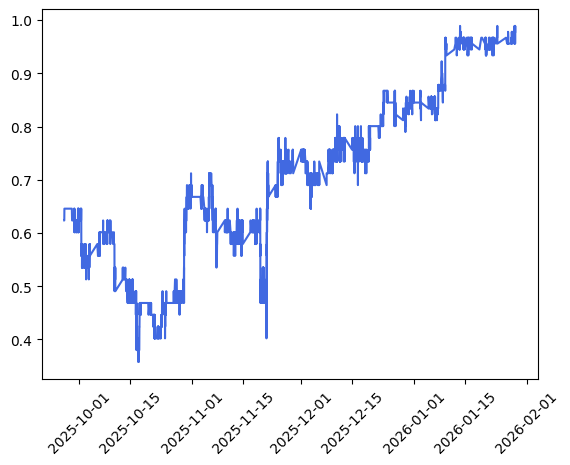

In [20]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [23]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_JAN_2026.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)